In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from sklearn.model_selection import train_test_split
from scipy.signal import find_peaks
import pandas as pd

In [2]:
data_path = "../UCI/data"
FS = 125
WINDOW_SIZE = 1000

In [3]:
from pre_processing import load_UCI_dataset

In [4]:
def extract_bp_from_abp(abp_window):

    # Detect systolic peaks
    peaks, _ = find_peaks(
        abp_window,
        distance=50,       # ~0.4 sec at 125 Hz
        prominence=5
    )


    # Need enough beats in the window
    if len(peaks) < 2:
        return None, None


    # SBP = pressure at systolic peaks
    sbp_values = abp_window[peaks]


    dbp_values = []


    # Find minimum pressure between consecutive systolic peaks
    for i in range(len(peaks)-1):

        beat_segment = abp_window[
            peaks[i]:peaks[i+1]
        ]

        if len(beat_segment) > 0:

            dbp_values.append(
                np.min(beat_segment)
            )


    if len(dbp_values) == 0:
        return None, None


    # Use median to reduce effect of noisy beats
    sbp = np.median(sbp_values)
    dbp = np.median(dbp_values)


    # Optional sanity check
    if sbp < 50 or sbp > 250:
        return None, None

    if dbp < 20 or dbp > 150:
        return None, None


    return sbp, dbp

In [5]:
def process_recording(
    recording,
    window_size=1000,
    step_size=500,
    fs=125
):

    data = recording[:]

    # -----------------------------------------
    # Extract channels
    # -----------------------------------------

    ppg = data[:, 0]
    abp = data[:, 1]

    # -----------------------------------------
    # Recording-level PPG normalization
    # -----------------------------------------

    mean = np.mean(ppg)
    std = np.std(ppg)

    if std == 0:
        return None, None, None

    ppg = (ppg - mean) / std

    X = []
    y = []
    delays = []

    # -----------------------------------------
    # Windowing
    # -----------------------------------------

    for start in range(
        0,
        len(ppg) - window_size + 1,
        step_size
    ):

        ppg_window = ppg[
            start:start + window_size
        ]

        abp_window = abp[
            start:start + window_size
        ]

        # -------------------------------------
        # Extract SBP / DBP
        # -------------------------------------

        sbp, dbp = extract_bp_from_abp(
            abp_window
        )

        if sbp is None:
            continue


        X.append(ppg_window)

        y.append([
            sbp,
            dbp
        ])

    if len(X) == 0:
        return None, None, None

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32))



In [6]:
def process_split(
    records,
    window_size=1000,
    step_size=500,
    fs=125
):
    """
    Process all recordings belonging to one split.

    Each recording is:
        1. Loaded
        2. PPG normalized at recording level
        3. Windowed
        4. SBP/DBP extracted from corresponding ABP window

    Returns:
        X : (N, 1000)
        y : (N, 2)
    """

    X_all = []
    y_all = []

    for idx, (f, reference) in enumerate(records):

        # -----------------------------------------
        # Load complete recording
        # -----------------------------------------

        recording = f[reference]

        # -----------------------------------------
        # Process recording
        # -----------------------------------------

        result = process_recording(
            recording,
            window_size=window_size,
            step_size=step_size,
            fs=fs
        )

        if result[0] is None:
            continue

        X_recording, y_recording = result

        # -----------------------------------------
        # Store windows from this recording
        # -----------------------------------------

        X_all.append(X_recording)
        y_all.append(y_recording)

        # -----------------------------------------
        # Progress
        # -----------------------------------------

        if (idx + 1) % 500 == 0:
            print(
                f"Processed {idx + 1}/{len(records)} recordings"
            )

    # -----------------------------------------
    # Combine all recordings
    # -----------------------------------------

    if len(X_all) == 0:
        return None, None

    X_all = np.concatenate(
        X_all,
        axis=0
    )

    y_all = np.concatenate(
        y_all,
        axis=0
    )

    return X_all, y_all

In [7]:
recordings = []

for part in range(1,5):

    file_path = f"{data_path}/Part_{part}.mat"

    f = h5py.File(file_path, "r")

    dataset = f[f"Part_{part}"]


    for i in range(dataset.shape[0]):

        recordings.append(
            (f, dataset[i,0])
        )


print("Total recordings:", len(recordings))

Total recordings: 12000


In [8]:
train_records, test_records = train_test_split(recordings,test_size=0.2, random_state=42)
train_records, val_records = train_test_split(train_records,test_size=0.125, random_state=42)

print(f"Train recordings: {len(train_records)}")
print(f"Validation recordings: {len(val_records)}")
print(f"Test recordings: {len(test_records)}")

Train recordings: 8400
Validation recordings: 1200
Test recordings: 2400


In [9]:
X_train, y_train = process_split(train_records)
X_test, y_test = process_split(test_records)
X_val, y_val = process_split(val_records)

Processed 500/8400 recordings
Processed 1000/8400 recordings
Processed 1500/8400 recordings
Processed 2000/8400 recordings
Processed 2500/8400 recordings
Processed 3000/8400 recordings
Processed 3500/8400 recordings
Processed 4000/8400 recordings
Processed 4500/8400 recordings
Processed 5000/8400 recordings
Processed 5500/8400 recordings
Processed 6000/8400 recordings
Processed 6500/8400 recordings
Processed 7000/8400 recordings
Processed 7500/8400 recordings
Processed 8000/8400 recordings
Processed 500/2400 recordings
Processed 1000/2400 recordings
Processed 1500/2400 recordings
Processed 2000/2400 recordings
Processed 500/1200 recordings
Processed 1000/1200 recordings


## Signal Quality Index ##

In [10]:
def check_basic_validity(x):
    """
    Returns 1 if the window contains only finite values,
    otherwise 0.
    """
    x = np.asarray(x)

    return int(np.all(np.isfinite(x)))

In [11]:
def calculate_std(x):
    x = np.asarray(x, dtype=np.float64)
    return np.std(x)

In [12]:
def calculate_std(x):
    x = np.asarray(x, dtype=np.float64)
    return np.std(x)

In [13]:
from scipy.stats import skew

def calculate_skewness(x):
    x = np.asarray(x, dtype=np.float64)

    return skew(x)

In [14]:
from scipy.stats import kurtosis

def calculate_kurtosis(x):
    x = np.asarray(x, dtype=np.float64)

    return kurtosis(x)

In [15]:
def calculate_max_derivative(x):
    x = np.asarray(x, dtype=np.float64)

    dx = np.diff(x)

    return np.max(np.abs(dx))

In [16]:
def calculate_mean_derivative(x):
    x = np.asarray(x, dtype=np.float64)

    dx = np.diff(x)

    return np.mean(np.abs(dx))

In [17]:
def calculate_extreme_fraction(
    x,
    threshold=4.0
):

    x = np.asarray(x, dtype=np.float64)

    return np.mean(
        np.abs(x) > threshold
    )

In [18]:
def calculate_energy(x):

    x = np.asarray(x, dtype=np.float64)

    return np.mean(
        x ** 2
    )

In [19]:
from scipy import signal
def calculate_autocorrelation_peak(
    x,
    fs=125,
    min_hr=40,
    max_hr=200
):

    x = np.asarray(x, dtype=np.float64)

    # Remove mean
    x = x - np.mean(x)

    # Autocorrelation
    autocorr = signal.correlate(
        x,
        x,
        mode="full"
    )

    autocorr = autocorr[
        len(x)-1:
    ]

    # Normalize
    if autocorr[0] == 0:
        return np.nan

    autocorr = (
        autocorr /
        autocorr[0]
    )

    # Physiological lag range
    min_lag = int(
        fs * 60 / max_hr
    )

    max_lag = int(
        fs * 60 / min_hr
    )

    max_lag = min(
        max_lag,
        len(autocorr)-1
    )

    if min_lag >= max_lag:
        return np.nan

    region = autocorr[
        min_lag:max_lag+1
    ]

    return np.max(region)

In [20]:
def calculate_peak_interval_cv(
    x,
    fs=125
):

    x = np.asarray(x, dtype=np.float64)

    distance = int(
        fs * 60 / 200
    )

    peaks, _ = signal.find_peaks(
        x,
        distance=distance
    )

    if len(peaks) < 3:
        return np.nan

    intervals = np.diff(peaks) / fs

    mean_interval = np.mean(intervals)

    if mean_interval == 0:
        return np.nan

    return (
        np.std(intervals) /
        mean_interval
    )

In [21]:
def calculate_entropy(
    x,
    bins=50
):

    x = np.asarray(x, dtype=np.float64)

    hist, _ = np.histogram(
        x,
        bins=bins,
        density=True
    )

    hist = hist[
        hist > 0
    ]

    probabilities = (
        hist /
        np.sum(hist)
    )

    entropy = -np.sum(
        probabilities *
        np.log2(probabilities)
    )

    return entropy

In [22]:
def calculate_all_sqi(
    X,
    fs=125
):

    results = []

    total = len(X)

    for i, x in enumerate(X):

        if i % 10000 == 0:

            print(
                f"Processed "
                f"{i}/{total}"
            )

        # Basic
        finite = check_basic_validity(x)

        if not finite:

            results.append({
                "finite": 0,
                "std": np.nan,
                "skewness": np.nan,
                "kurtosis": np.nan,
                "max_derivative": np.nan,
                "mean_derivative": np.nan,
                "extreme_fraction": np.nan,
                "energy": np.nan,
                "total_power": np.nan,
                "cardiac_power": np.nan,
                "spectral_ratio": np.nan,
                "autocorr": np.nan,
                "peak_count": np.nan,
                "peak_interval_cv": np.nan,
                "derivative_extrema": np.nan,
                "entropy": np.nan
            })

            continue

        # -------------------------------------
        # Basic statistics
        # -------------------------------------

        std = calculate_std(x)

        skewness = calculate_skewness(x)

        kurt = calculate_kurtosis(x)

        # -------------------------------------
        # Derivatives
        # -------------------------------------

        max_derivative = calculate_max_derivative(x)

        mean_derivative = calculate_mean_derivative(x)

        # -------------------------------------
        # Extreme samples
        # -------------------------------------

        extreme_fraction = calculate_extreme_fraction(x)

        # -------------------------------------
        # Energy
        # -------------------------------------

        energy = calculate_energy(x)

        

        # -------------------------------------
        # Periodicity
        # -------------------------------------

        autocorr = calculate_autocorrelation_peak(
            x,
            fs
        )


        peak_interval_cv = calculate_peak_interval_cv(
            x,
            fs
        )


        # -------------------------------------
        # Entropy
        # -------------------------------------

        entropy = calculate_entropy(x)

        results.append({
            "finite": finite,
            "std": std,
            "skewness": skewness,
            "kurtosis": kurt,
            "max_derivative": max_derivative,
            "mean_derivative": mean_derivative,
            "extreme_fraction": extreme_fraction,
            "energy": energy,
            "autocorr": autocorr,
            "peak_interval_cv": peak_interval_cv,
            "entropy": entropy
        })

    return pd.DataFrame(results)

In [23]:
sqi_train = calculate_all_sqi(
    X_train,
    fs=125
)

Processed 0/455784
Processed 10000/455784
Processed 20000/455784
Processed 30000/455784
Processed 40000/455784
Processed 50000/455784
Processed 60000/455784
Processed 70000/455784
Processed 80000/455784
Processed 90000/455784
Processed 100000/455784
Processed 110000/455784
Processed 120000/455784
Processed 130000/455784
Processed 140000/455784
Processed 150000/455784
Processed 160000/455784
Processed 170000/455784
Processed 180000/455784
Processed 190000/455784
Processed 200000/455784
Processed 210000/455784
Processed 220000/455784
Processed 230000/455784
Processed 240000/455784
Processed 250000/455784
Processed 260000/455784
Processed 270000/455784
Processed 280000/455784
Processed 290000/455784
Processed 300000/455784
Processed 310000/455784
Processed 320000/455784
Processed 330000/455784
Processed 340000/455784
Processed 350000/455784
Processed 360000/455784
Processed 370000/455784
Processed 380000/455784
Processed 390000/455784
Processed 400000/455784
Processed 410000/455784
Proces

In [27]:
def plot_all_sqi_distributions(sqi_df):

    columns = [
        "std",
        "skewness",
        "kurtosis",
        "max_derivative",
        "mean_derivative",
        # "extrema_fraction",
        "energy",
        "autocorr",
        "peak_interval_cv",
        "entropy"
    ]

    for column in columns:

        values = sqi_df[column].dropna()

        plt.figure(figsize=(8, 4))

        plt.hist(
            values,
            bins=100
        )

        plt.xlabel(column)
        plt.ylabel("Number of windows")
        plt.title(
            f"Distribution of {column}"
        )

        plt.grid(
            alpha=0.3
        )

        plt.show()

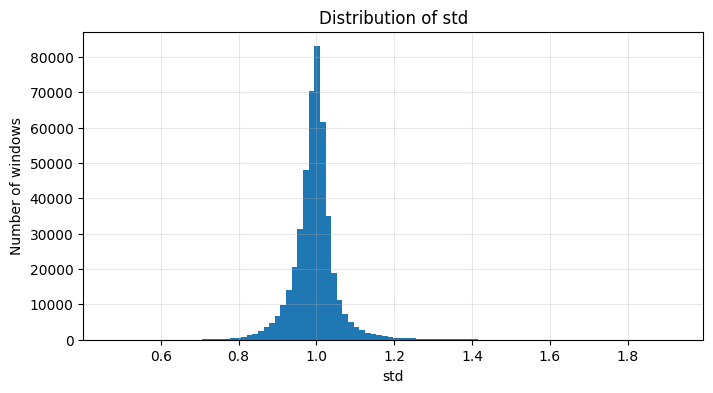

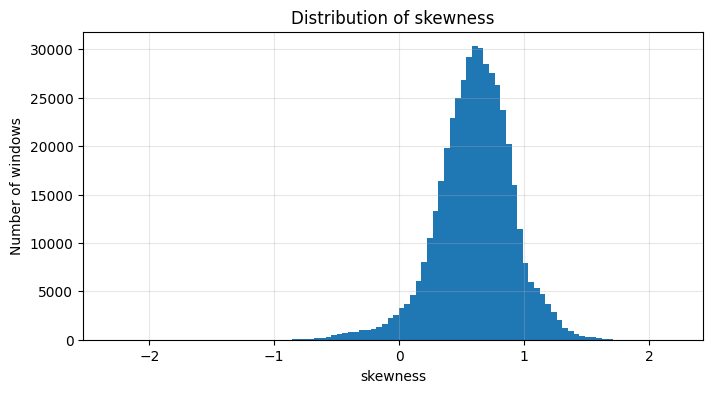

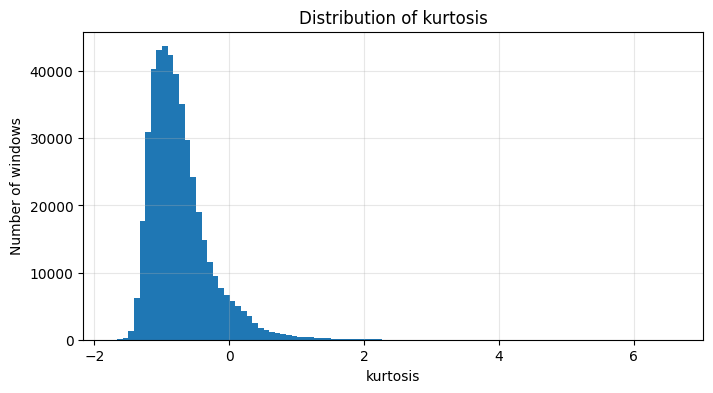

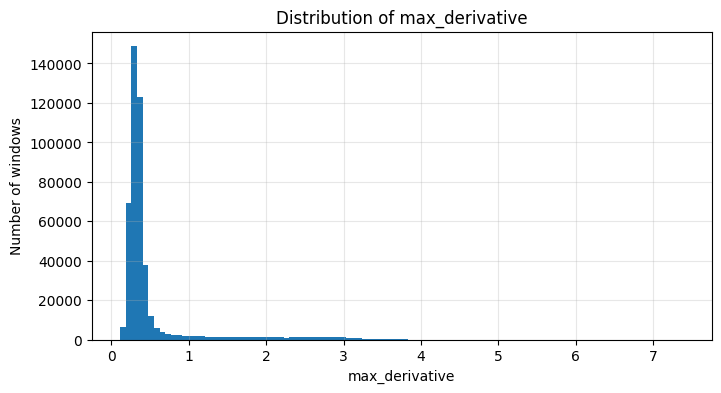

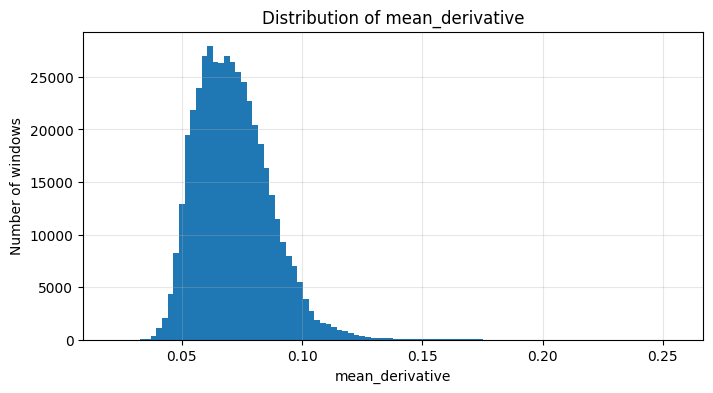

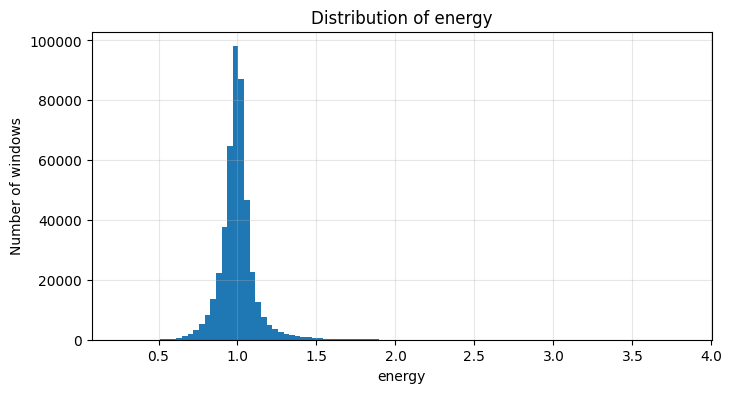

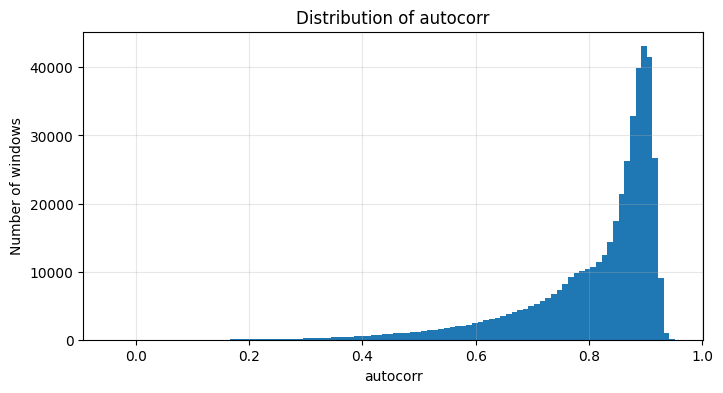

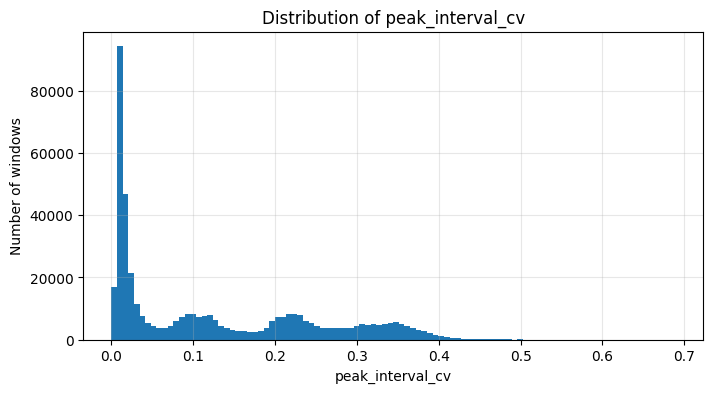

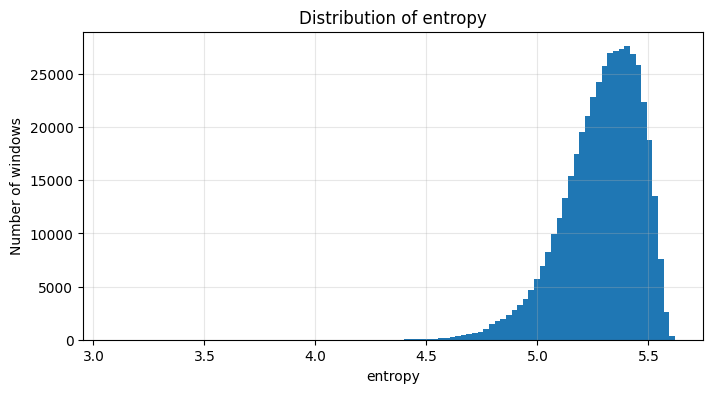

In [28]:
plot_all_sqi_distributions(
    sqi_train
)